# Data Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch
import seaborn as sns
import os
from pathlib import Path
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [15]:
original_pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_03\segment"
original_pt_files = [f for f in os.listdir(original_pt_dir) if f.endswith('.pt')]
#load pt file into pandas dataframe
pt_files = sorted(Path(original_pt_dir).rglob("*.pt"))

print(f"Found {len(pt_files)} .pt files")

sample = torch.load(
    pt_files[0],
    map_location="cpu",
    weights_only=False
)

print(type(sample))

Found 1065 .pt files
<class 'dict'>


In [16]:
#key names
sample_feats = sample["features"]
key_feats = list(sample_feats.keys())
labels = ["task_id","task_progress","mistake"]

In [17]:
all_frames = []

for participant_idx, path in enumerate(pt_files):

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )
    data = data["labels"]

    step_ids = data["task_id"].detach().cpu().numpy()
    progress = data["task_progress"].detach().cpu().numpy()
    mistake = data["mistake"].detach().cpu().numpy()

    #convert to numpy array and squeeze to remove extra dimensions
    step_ids = np.asarray(step_ids).squeeze()
    progress = np.asarray(progress).squeeze()
    mistake = np.asarray(mistake).squeeze()

    n_frames = len(step_ids)

    participant_name = path.stem

    participant_df = pd.DataFrame({
        "participant": participant_name,
        "frame_idx": np.arange(n_frames),
        "task_id": step_ids,
        "task_progress": progress,
        "mistake": mistake
    })

    all_frames.append(participant_df)


df = pd.concat(
    all_frames,
    ignore_index=True
)

print(df.head())
print(df.shape)


                              participant  frame_idx  task_id  task_progress  \
0  features__cam-05_uid-01_take-02_seg-00          0        0            0.0   
1  features__cam-05_uid-01_take-02_seg-00          1        0            0.0   
2  features__cam-05_uid-01_take-02_seg-00          2        0            0.0   
3  features__cam-05_uid-01_take-02_seg-00          3        0            0.0   
4  features__cam-05_uid-01_take-02_seg-00          4        0            0.0   

   mistake  
0        0  
1        0  
2        0  
3        0  
4        0  
(1019615, 5)


In [18]:
print(df.tail())

                                    participant  frame_idx  task_id  \
1019610  features__cam-07_uid-15_take-02_seg-13        642        0   
1019611  features__cam-07_uid-15_take-02_seg-13        643        0   
1019612  features__cam-07_uid-15_take-02_seg-13        644        0   
1019613  features__cam-07_uid-15_take-02_seg-13        645        0   
1019614  features__cam-07_uid-15_take-02_seg-13        646        0   

         task_progress  mistake  
1019610            0.0        0  
1019611            0.0        0  
1019612            0.0        0  
1019613            0.0        0  
1019614            0.0        0  


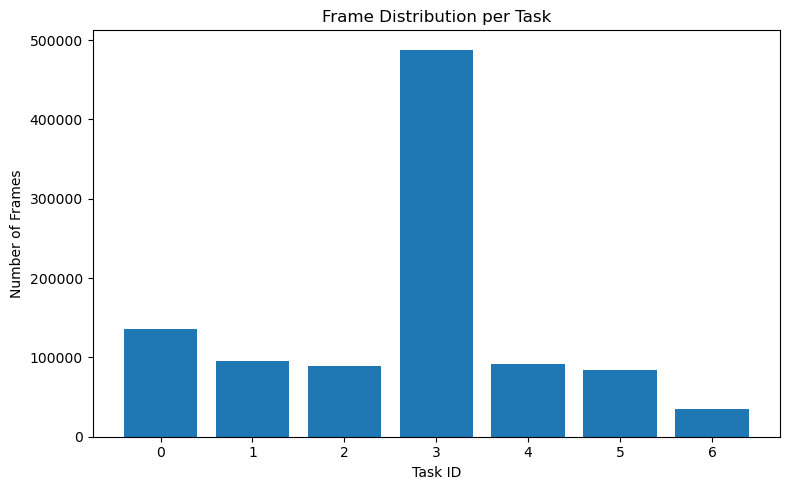

In [19]:
import matplotlib.pyplot as plt

frame_counts = (
    df["task_id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    frame_counts.index.astype(str),
    frame_counts.values
)

plt.xlabel("Task ID")
plt.ylabel("Number of Frames")
plt.title("Frame Distribution per Task")

plt.tight_layout()
plt.show()

In [21]:
FPS = 30

segments = (
    df.groupby(
        [
            "participant",
            
            "task_id"
        ]
    )
    .agg(
        start_frame=("frame_idx", "min"),
        end_frame=("frame_idx", "max"),
        n_frames=("frame_idx", "size")
    )
    .reset_index()
)

segments["duration_s"] = (
    segments["n_frames"] / FPS
)

print(segments.head())

                              participant  task_id  start_frame  end_frame  \
0  features__cam-05_uid-01_take-02_seg-00        0            0        340   
1  features__cam-05_uid-01_take-02_seg-00        1          341        999   
2  features__cam-05_uid-01_take-02_seg-00        6          514        750   
3  features__cam-05_uid-01_take-02_seg-01        1            0        669   
4  features__cam-05_uid-01_take-02_seg-01        2          670        999   

   n_frames  duration_s  
0       341   11.366667  
1       422   14.066667  
2       237    7.900000  
3       509   16.966667  
4       330   11.000000  


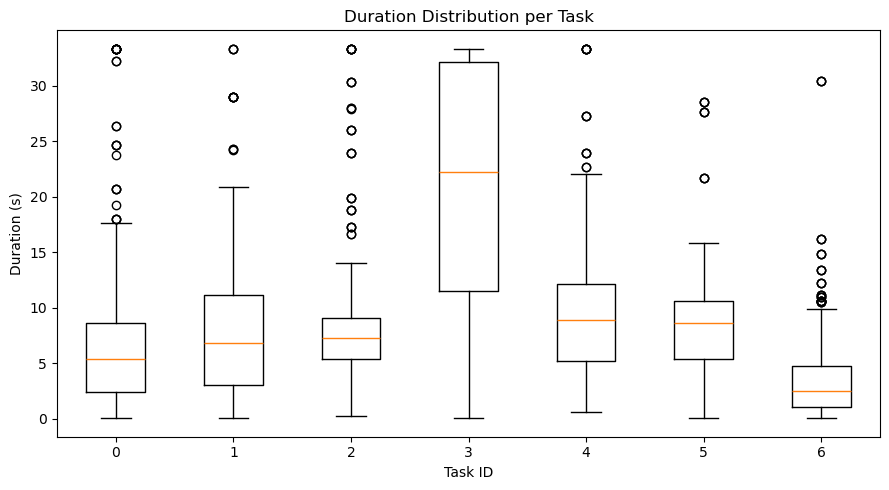

In [22]:
steps = sorted(
    segments["task_id"].unique()
)

duration_data = [
    segments.loc[
        segments["task_id"] == step,
        "duration_s"
    ].values
    for step in steps
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    duration_data,
    tick_labels=[str(s) for s in steps]
)

plt.xlabel("Task ID")
plt.ylabel("Duration (s)")
plt.title("Duration Distribution per Task")

plt.tight_layout()
plt.show()

In [23]:
for name, value in sample["features"].items():
    print(
        f"{name:30s}",
        type(value),
        getattr(value, "shape", None)
    )

joint_speed                    <class 'torch.Tensor'> torch.Size([1000, 16])
joint_acceleration             <class 'torch.Tensor'> torch.Size([1000, 16])
joint_velocity_x               <class 'torch.Tensor'> torch.Size([1000, 16])
joint_velocity_y               <class 'torch.Tensor'> torch.Size([1000, 16])
joint_velocity_z               <class 'torch.Tensor'> torch.Size([1000, 16])
joint_acceleration_x           <class 'torch.Tensor'> torch.Size([1000, 16])
joint_acceleration_y           <class 'torch.Tensor'> torch.Size([1000, 16])
joint_acceleration_z           <class 'torch.Tensor'> torch.Size([1000, 16])
position_x_relative_to_pelvis  <class 'torch.Tensor'> torch.Size([1000, 16])
position_y_relative_to_pelvis  <class 'torch.Tensor'> torch.Size([1000, 16])
position_z_relative_to_pelvis  <class 'torch.Tensor'> torch.Size([1000, 16])
polar_azimuth                  <class 'torch.Tensor'> torch.Size([1000, 16])
polar_elevation                <class 'torch.Tensor'> torch.Size([1000, 16])

# Load traning dataset

In [7]:
train_pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_03\original"
pt_files = sorted(Path(train_pt_dir).rglob("*.pt"))

In [8]:
all_features = []
loaded_pt_paths = []
all_tasks = []
all_progress = []
all_participants = []

for path in pt_files:

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    data_features = data["features"]
    data_labels = data["labels"]

    feature_tensors = []

    for feature_name, feature_value in data["features"].items():

        x = (
            feature_value
            .detach()
            .cpu()
            .float()
        )

        x = x.reshape(x.shape[0], -1)

        feature_tensors.append(x)

    X = torch.cat(
        feature_tensors,
        dim=1
    )

    task = (
        data_labels["task_id"]
        .detach()
        .cpu()
        .numpy()
        .squeeze()
    )

    progress = (
        data_labels["task_progress"]
        .detach()
        .cpu()
        .numpy()
        .squeeze()
    )

    all_features.append(X)
    loaded_pt_paths.append(str(path))

    all_tasks.append(task)
    all_progress.append(progress)

    all_participants.extend(
        [path.stem] * len(task)
    )


X_all = torch.cat(
    all_features,
    dim=0
).numpy()

y_task = np.concatenate(all_tasks)
y_progress = np.concatenate(all_progress)

print("X:", X_all.shape)
print("Task:", y_task.shape)
print("Progress:", y_progress.shape)

X: (1064615, 235)
Task: (1064615,)
Progress: (1064615,)


In [9]:
feature_names = []

for feature_name, feature_value in sample["features"].items():

    x = feature_value.reshape(
        feature_value.shape[0],
        -1
    )

    n_dims = x.shape[1]

    if n_dims == 1:
        feature_names.append(feature_name)
    else:
        feature_names.extend([
            f"{feature_name}_{i}"
            for i in range(n_dims)
        ])

print(len(feature_names))
print(feature_names[:20])

assert len(feature_names) == X_all.shape[1]

235
['joint_speed_0', 'joint_speed_1', 'joint_speed_2', 'joint_speed_3', 'joint_speed_4', 'joint_speed_5', 'joint_speed_6', 'joint_speed_7', 'joint_speed_8', 'joint_speed_9', 'joint_speed_10', 'joint_speed_11', 'joint_speed_12', 'joint_speed_13', 'joint_speed_14', 'joint_speed_15', 'joint_acceleration_0', 'joint_acceleration_1', 'joint_acceleration_2', 'joint_acceleration_3']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("X shape:", X_all.shape)

print(
    "NaN:",
    np.isnan(X_all).sum()
)

print(
    "Inf:",
    np.isinf(X_all).sum()
)

# NaN counts per feature dimension and per original feature.
feature_groups = []
expected_names = []
for name, value in data_features.items():
    n_dims = int(np.prod(value.shape[1:]))
    feature_groups.extend([name] * n_dims)
    expected_names.extend(
        [name] if n_dims == 1 else [f"{name}_{i}" for i in range(n_dims)]
    )

assert expected_names == feature_names, "Feature names do not match the training feature order."
assert len(feature_names) == X_all.shape[1]

nan_by_dimension = pd.DataFrame({
    "feature": feature_groups,
    "dimension": feature_names,
    "nan_count": np.isnan(X_all).sum(axis=0),
    "total_values": X_all.shape[0],
})
nan_by_dimension["nan_percent"] = (
    100 * nan_by_dimension["nan_count"] / nan_by_dimension["total_values"]
)

nan_by_feature = (
    nan_by_dimension.groupby("feature", sort=False)[["nan_count", "total_values"]]
    .sum()
)
nan_by_feature["nan_percent"] = (
    100 * nan_by_feature["nan_count"] / nan_by_feature["total_values"]
)
nan_by_feature = nan_by_feature.sort_values("nan_count", ascending=False)

print("\nNaN by feature (percentage of all values in that feature):")
print(nan_by_feature.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nDimensions containing NaN:")
print(
    nan_by_dimension.loc[nan_by_dimension["nan_count"] > 0]
    .sort_values("nan_count", ascending=False)
    .to_string(index=False, float_format=lambda value: f"{value:.4f}")
)


X shape: (1064615, 235)
NaN: 0
Inf: 0

NaN by feature (percentage of all values in that feature):
                               nan_count  total_values  nan_percent
feature                                                            
joint_speed                            0      17033840       0.0000
joint_acceleration                     0      17033840       0.0000
joint_velocity_x                       0      17033840       0.0000
joint_velocity_y                       0      17033840       0.0000
joint_velocity_z                       0      17033840       0.0000
joint_acceleration_x                   0      17033840       0.0000
joint_acceleration_y                   0      17033840       0.0000
joint_acceleration_z                   0      17033840       0.0000
position_x_relative_to_pelvis          0      17033840       0.0000
position_y_relative_to_pelvis          0      17033840       0.0000
position_z_relative_to_pelvis          0      17033840       0.0000
polar_azimuth     

In [ ]:
# Locate NaN frames in the exact .pt files used to build X_all.
# Frame indices are zero-based within each .pt file, not the original video.
assert len(loaded_pt_paths) == len(all_features)
assert sum(x.shape[0] for x in all_features) == X_all.shape[0]

file_rows = []
frame_tables = []
range_rows = []

for pt_path, features in zip(loaded_pt_paths, all_features):
    values = features.numpy()
    nan_counts = np.isnan(values).sum(axis=1)
    bad_frames = np.flatnonzero(nan_counts)
    if bad_frames.size == 0:
        continue

    full_nan = nan_counts == values.shape[1]
    file_rows.append({
        "pt_file": pt_path,
        "total_frames": len(values),
        "nan_frames": len(bad_frames),
        "full_nan_frames": int(full_nan.sum()),
        "partial_nan_frames": int(((nan_counts > 0) & ~full_nan).sum()),
        "nan_values": int(nan_counts.sum()),
    })
    frame_tables.append(pd.DataFrame({
        "pt_file": pt_path,
        "frame_idx": bad_frames,
        "nan_dimensions": nan_counts[bad_frames],
        "all_features_nan": full_nan[bad_frames],
    }))

    # Split consecutive bad frames into ranges; endpoints are inclusive.
    runs = np.split(bad_frames, np.flatnonzero(np.diff(bad_frames) > 1) + 1)
    for run in runs:
        range_rows.append({
            "pt_file": pt_path,
            "start_frame": int(run[0]),
            "end_frame": int(run[-1]),
            "nan_frames": len(run),
            "full_nan_frames": int(full_nan[run].sum()),
        })

nan_files = pd.DataFrame(file_rows, columns=[
    "pt_file", "total_frames", "nan_frames", "full_nan_frames",
    "partial_nan_frames", "nan_values",
]).sort_values("nan_frames", ascending=False)
nan_frames = pd.concat(frame_tables, ignore_index=True) if frame_tables else pd.DataFrame(
    columns=["pt_file", "frame_idx", "nan_dimensions", "all_features_nan"]
)
nan_ranges = pd.DataFrame(range_rows, columns=[
    "pt_file", "start_frame", "end_frame", "nan_frames", "full_nan_frames",
])

print(f"Files containing NaN: {len(nan_files)} / {len(loaded_pt_paths)}")
print("\nNaN summary by file:")
print(nan_files.to_string(index=False))
print("\nConsecutive NaN frame ranges (zero-based, inclusive):")
print(nan_ranges.to_string(index=False))
# Inspect nan_frames for every affected frame, e.g. nan_frames.head(20).


Files containing NaN: 4 / 93

NaN summary by file:
                                                                                                                                                                       pt_file  total_frames  nan_frames  full_nan_frames  partial_nan_frames  nan_values
G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\original\features__cam-07_uid-10_take-01.pt         40097         355              355                   0       83425
G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\original\features__cam-07_uid-06_take-01.pt         11304          90               90                   0       21150
G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\original\features__cam-05_uid-06_take-01.pt         11382          3

In [43]:
feature_stats = pd.DataFrame({
    "feature": feature_names,
    "mean": np.nanmean(X_all, axis=0),
    "std": np.nanstd(X_all, axis=0),
    "min": np.nanmin(X_all, axis=0),
    "max": np.nanmax(X_all, axis=0),
})

feature_stats["range"] = (
    feature_stats["max"] -
    feature_stats["min"]
)

print(
    feature_stats
    .sort_values("std")
    .head(20)
)

                             feature      mean       std       min       max  \
226           distance_from_center_7  1.000000  0.000000  1.000000  1.000000   
160  position_z_relative_to_pelvis_0 -0.000859  0.008162 -0.135100  0.152787   
163  position_z_relative_to_pelvis_3 -0.001867  0.008290 -0.126949  0.123624   
225           distance_from_center_6  0.492677  0.011275  0.383928  0.577483   
219           distance_from_center_0  0.216486  0.020349  0.086572  0.365515   
150  position_y_relative_to_pelvis_6 -0.051796  0.022512 -0.324427  0.316931   
222           distance_from_center_3  0.211648  0.026075  0.067260  0.354660   
166  position_z_relative_to_pelvis_6  0.278567  0.028311 -0.120217  0.481159   
67                joint_velocity_z_3 -0.000014  0.032264 -2.977344  2.513505   
64                joint_velocity_z_0  0.000006  0.032809 -3.048831  4.230714   
229          distance_from_center_10  1.019522  0.035870  0.742269  1.339396   
232          distance_from_center_13  1.

# low variance features

In [44]:
LOW_VARIANCE_THRESHOLD = 1e-6

low_variance_features = feature_stats[
    feature_stats["std"] < LOW_VARIANCE_THRESHOLD
]

print(
    "Low variance features:",
    len(low_variance_features)
)

print(
    low_variance_features[
        ["feature", "std", "min", "max"]
    ]
)

Low variance features: 1
                    feature  std  min  max
226  distance_from_center_7  0.0  1.0  1.0


# feature-feature correlation

(235, 235)


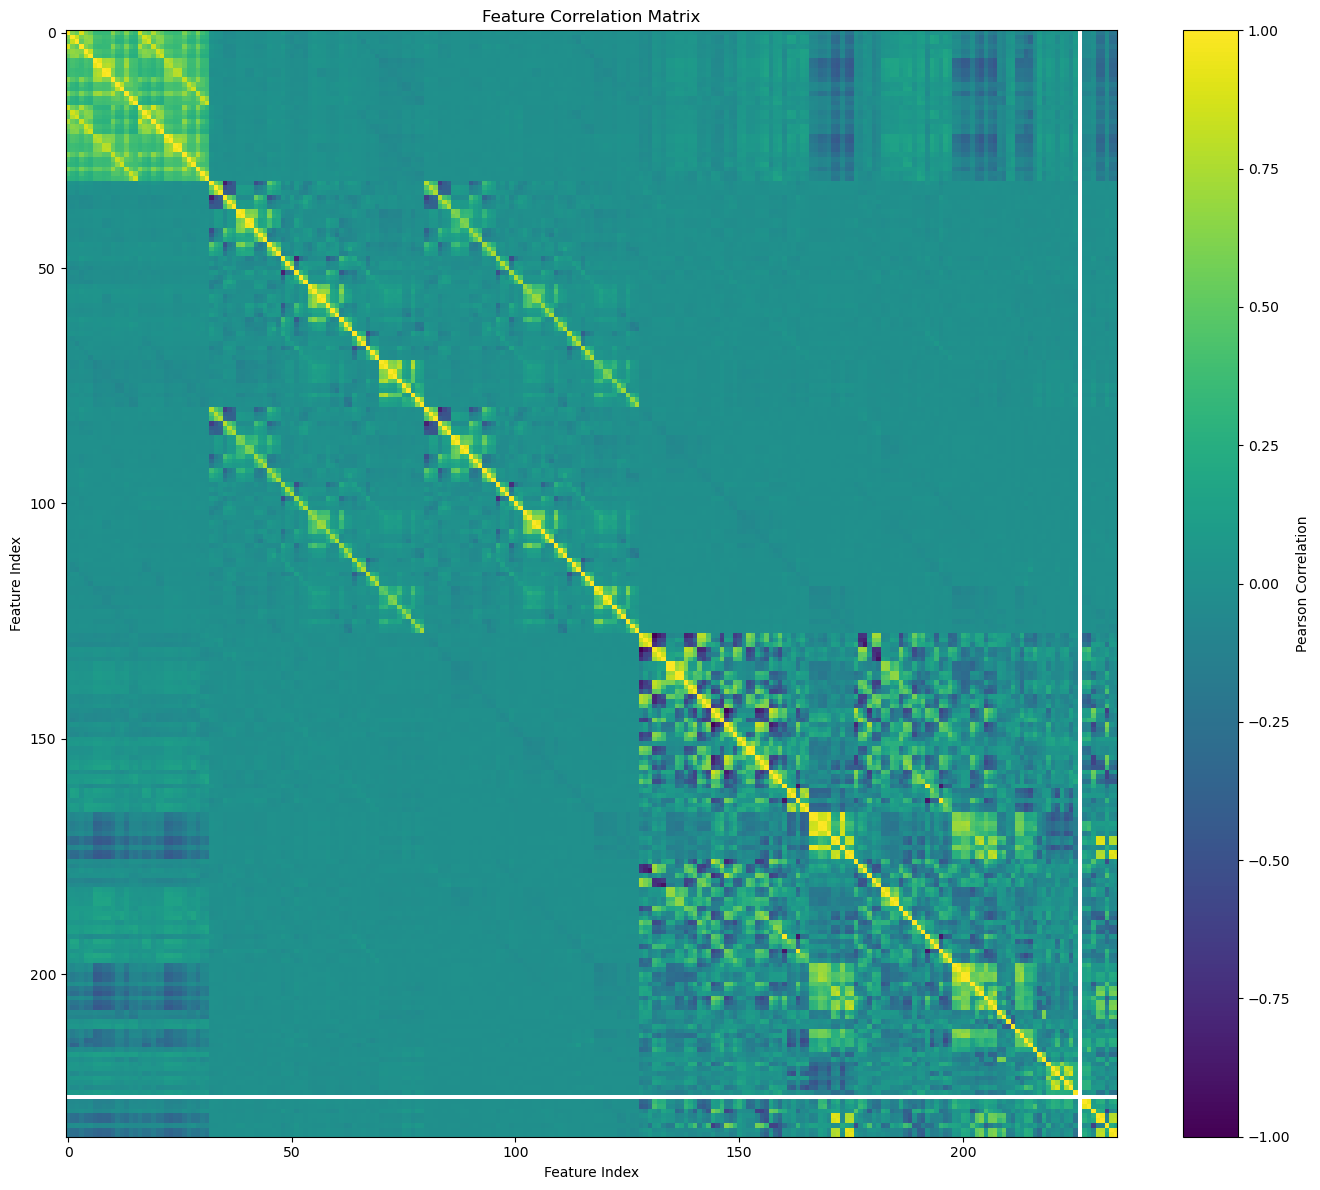

In [45]:
feature_df = pd.DataFrame(
    X_all,
    columns=feature_names
)
corr_matrix = feature_df.corr(
    method="pearson"
)

print(corr_matrix.shape)

plt.figure(figsize=(14, 12))

plt.imshow(
    corr_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.xlabel("Feature Index")
plt.ylabel("Feature Index")

plt.tight_layout()
plt.show()

In [46]:
CORR_THRESHOLD = 0.95

high_corr_pairs = []

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) >= CORR_THRESHOLD:

            high_corr_pairs.append({
                "feature_1": feature_names[i],
                "feature_2": feature_names[j],
                "correlation": corr
            })

high_corr_df = pd.DataFrame(
    high_corr_pairs
)

if len(high_corr_df) > 0:
    high_corr_df["abs_corr"] = (
        high_corr_df["correlation"].abs()
    )

    high_corr_df = (
        high_corr_df
        .sort_values(
            "abs_corr",
            ascending=False
        )
    )

print(high_corr_df.head(30))

                           feature_1                         feature_2  \
4    position_x_relative_to_pelvis_6   position_x_relative_to_pelvis_7   
3    position_x_relative_to_pelvis_0   position_x_relative_to_pelvis_3   
8    position_z_relative_to_pelvis_0                 polar_elevation_0   
6    position_y_relative_to_pelvis_0   position_y_relative_to_pelvis_3   
9    position_z_relative_to_pelvis_3                 polar_elevation_3   
17                 polar_elevation_8                 polar_elevation_9   
10   position_z_relative_to_pelvis_6   position_z_relative_to_pelvis_7   
5    position_x_relative_to_pelvis_8   position_x_relative_to_pelvis_9   
15   position_z_relative_to_pelvis_8   position_z_relative_to_pelvis_9   
0                      joint_speed_8                     joint_speed_9   
13   position_z_relative_to_pelvis_7  position_z_relative_to_pelvis_10   
1               joint_acceleration_8              joint_acceleration_9   
7    position_y_relative_to_pelvis_8  

In [47]:
upper = corr_matrix.abs().where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

features_to_drop = [
    column
    for column in upper.columns
    if any(
        upper[column] > CORR_THRESHOLD
    )
]

print(
    "Potential redundant features:",
    len(features_to_drop)
)

print(features_to_drop)

Potential redundant features: 18
['joint_speed_9', 'joint_acceleration_9', 'joint_velocity_x_9', 'position_x_relative_to_pelvis_3', 'position_x_relative_to_pelvis_7', 'position_x_relative_to_pelvis_9', 'position_y_relative_to_pelvis_3', 'position_y_relative_to_pelvis_9', 'position_z_relative_to_pelvis_7', 'position_z_relative_to_pelvis_9', 'position_z_relative_to_pelvis_10', 'position_z_relative_to_pelvis_13', 'position_z_relative_to_pelvis_15', 'polar_elevation_0', 'polar_elevation_3', 'polar_elevation_9', 'distance_from_center_12', 'distance_from_center_15']


# PCA

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_clean
)

In [55]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_pca_full = pca_full.fit_transform(
    X_scaled
)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = (
    np.cumsum(explained_variance)
)

In [56]:
n_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

n_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components for 90%:",
    n_90
)

print(
    "Components for 95%:",
    n_95
)

Components for 90%: 72
Components for 95%: 101


In [ ]:
pca_2 = PCA(
    n_components=2
)

X_pca_2 = pca_2.fit_transform(
    X_scaled
)

print(
    "Explained variance:",
    pca_2.explained_variance_ratio_
)

rng = np.random.default_rng(42)

MAX_POINTS = 15000

if len(X_pca_2) > MAX_POINTS:

    indices = rng.choice(
        len(X_pca_2),
        MAX_POINTS,
        replace=False
    )

else:
    indices = np.arange(
        len(X_pca_2)
    )

plt.figure(figsize=(9, 7))

for step in np.unique(y_task):

    mask = (
        y_task[indices] == step
    )

    plt.scatter(
        X_pca_2[
            indices[mask],
            0
        ],
        X_pca_2[
            indices[mask],
            1
        ],
        s=8,
        alpha=0.3,
        label=f"Step {step}"
    )

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title(
    "PCA Projection of Motion Features"
)

plt.legend()

plt.tight_layout()
plt.show()

Explained variance: [0.09886948 0.06380958]


NameError: name 'y_step' is not defined

<Figure size 900x700 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="."
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95%"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.legend()

plt.tight_layout()
plt.show()

# MISSION: filter out useless features, select or combine the most representative features.

In [ ]:
# data.keys(): dict_keys([
# 'metadata', 
# 'features', 
# 'labels'])

# data_feat.keys(): dict_keys([
# 'joint_speed', 
# 'joint_acceleration', 
# 'joint_velocity_x', 
# 'joint_velocity_y', 
# 'joint_velocity_z', 
# 'joint_acceleration_x', 
# 'joint_acceleration_y', 
# 'joint_acceleration_z', 
# 'position_x_relative_to_pelvis', 
# 'position_y_relative_to_pelvis', 
# 'position_z_relative_to_pelvis', 
# 'polar_azimuth', 'polar_elevation', 
# 'joint_angles', 
# 'ratios', 
# 'distance_from_center'])

# data_label.keys(): dict_keys([
# 'step_id', >>>>
# 'step_id_prob', 
# 'status_id', 
# 'status_id_prob', 
# 'task_progress',  >>>>
# 'step_id_plateau', 
# 'step_id_plateau_prob', 
# 'status_id_plateau', 
# 'status_id_plateau_prob', 
# 'step_id_vector', 
# 'status_id_vector', 
# 'step_id_plateau_vector', 
# 'status_id_plateau_vector', 
# 'task_progress_vector'])

In [59]:
import torch
import numpy as np
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif,mutual_info_regression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

import shap

### flatten features + extract difference

In [60]:
def process_feature(name, val, prev_val=None):
    features = {}

    val = np.array(val)

    # ---------- scalar ----------
    if val.ndim == 0:
        features[name] = float(val)

        if prev_val is not None:
            diff = val - prev_val
            features[f"{name}_diff"] = float(diff)
            features[f"{name}_absdiff"] = float(abs(diff))

    # ---------- 2D vector ----------
    elif val.shape[-1] == 2:
        vx, vy = val
        mag = np.sqrt(vx**2 + vy**2)

        features[f"{name}_mag"] = float(mag)

        if prev_val is not None:
            pvx, pvy = prev_val
            prev_mag = np.sqrt(pvx**2 + pvy**2)

            diff = mag - prev_mag
            features[f"{name}_mag_diff"] = float(diff)
            features[f"{name}_mag_absdiff"] = float(abs(diff))

    # ---------- multi-dim ----------
    else:
        mean = np.mean(val)
        std = np.std(val)

        features[f"{name}_mean"] = float(mean)
        features[f"{name}_std"] = float(std)

        if prev_val is not None:
            prev_val = np.array(prev_val)
            prev_mean = np.mean(prev_val)

            diff = mean - prev_mean
            features[f"{name}_mean_diff"] = float(diff)
            features[f"{name}_mean_absdiff"] = float(abs(diff))

    return features

In [67]:
raw_pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_02\train\raw"
pt_files = glob.glob(os.path.join(raw_pt_dir, "*aug-01_seg-00.pt"))

all_rows = []

for seq_id, pt_file in enumerate(pt_files):
    data = torch.load(pt_file)

    features = data["features"]
    labels = data["labels"]

    T = len(labels["task_id"])

    prev_frame = {}

    for t in range(T):
        row = {}

        for k, v in features.items():
            val = v[t]

            if hasattr(val, "detach"):
                val = val.detach().cpu().numpy()

            prev_val = prev_frame.get(k, None)

            processed = process_feature(k, val, prev_val)
            row.update(processed)

            prev_frame[k] = val

        row["task_id"] = int(labels["task_id"][t])
        row["task_progress"] = float(labels["task_progress"][t])
        row["task_id_prob"] = float(labels["task_id_prob"][t])
        row["t"] = t

        all_rows.append(row)

df = pd.DataFrame(all_rows)

print("Data shape:", df.shape)

Data shape: (69000, 67)


In [68]:
df.fillna(0, inplace=True)
df.head()

,joint_speed_mean,joint_speed_std,joint_acceleration_mean,joint_acceleration_std,joint_velocity_x_mean,joint_velocity_x_std,joint_velocity_y_mean,joint_velocity_y_std,joint_velocity_z_mean,joint_velocity_z_std,...,polar_azimuth_mean_diff,polar_azimuth_mean_absdiff,polar_elevation_mean_diff,polar_elevation_mean_absdiff,joint_angles_mean_diff,joint_angles_mean_absdiff,ratios_mag_diff,ratios_mag_absdiff,distance_from_center_mean_diff,distance_from_center_mean_absdiff
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.135071,0.135071,0.099884,0.099884,-0.173813,0.173813,-0.010698,0.010698,0.000827,0.000827
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.055538,0.055538,0.070934,0.070934,-0.169586,0.169586,-0.007769,0.007769,0.000634,0.000634
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050850,0.050850,0.012104,0.012104,-0.121613,0.121613,-0.004436,0.004436,0.000288,0.000288
4,0.024247,0.012018,0.659241,0.594601,-0.003112,0.016867,0.008944,0.009822,-0.009977,0.012734,...,0.047424,0.047424,0.012615,0.012615,-0.071320,0.071320,-0.002946,0.002946,0.000351,0.000351


# StandardScaler

In [69]:
#standardscaler 
scaler = StandardScaler()

#for feature columns
feature_cols = [col for col in df.columns if col not in ["step_id", "t","step_change"]]
df [feature_cols] = scaler.fit_transform(df[feature_cols])

df.head()


,joint_speed_mean,joint_speed_std,joint_acceleration_mean,joint_acceleration_std,joint_velocity_x_mean,joint_velocity_x_std,joint_velocity_y_mean,joint_velocity_y_std,joint_velocity_z_mean,joint_velocity_z_std,...,polar_azimuth_mean_diff,polar_azimuth_mean_absdiff,polar_elevation_mean_diff,polar_elevation_mean_absdiff,joint_angles_mean_diff,joint_angles_mean_absdiff,ratios_mag_diff,ratios_mag_absdiff,distance_from_center_mean_diff,distance_from_center_mean_absdiff
0,-0.884812,-0.766845,-0.820603,-0.704366,0.001460,-0.735151,-0.001151,-0.823365,0.001495,-0.713382,...,-0.000960,-0.328430,-0.008552,-0.510660,0.021983,-0.668487,0.031802,-0.583792,-0.007978,-0.602894
1,-0.884812,-0.766845,-0.820603,-0.704366,0.001460,-0.735151,-0.001151,-0.823365,0.001495,-0.713382,...,0.030135,-0.295700,0.292597,-0.172530,-0.205090,-0.395416,-0.454712,-0.020725,0.198839,-0.361406
2,-0.884812,-0.766845,-0.820603,-0.704366,0.001460,-0.735151,-0.001151,-0.823365,0.001495,-0.713382,...,0.011826,-0.314972,0.205314,-0.270532,-0.199568,-0.402056,-0.321509,-0.174887,0.150450,-0.417907
3,-0.884812,-0.766845,-0.820603,-0.704366,0.001460,-0.735151,-0.001151,-0.823365,0.001495,-0.713382,...,0.010746,-0.316108,0.027942,-0.469685,-0.136895,-0.477426,-0.169955,-0.350288,0.063891,-0.518977
4,-0.793946,-0.726005,-0.655910,-0.579414,-0.020321,-0.672971,0.088884,-0.766415,-0.087560,-0.648638,...,0.009958,-0.316938,0.029483,-0.467955,-0.071191,-0.556439,-0.102192,-0.428714,0.079832,-0.500363


In [70]:
df["task_id_prob"].describe()

count    6.900000e+04
mean    -1.812399e-16
std      1.000007e+00
min     -1.735396e+00
25%     -8.951151e-01
50%      4.240168e-01
75%      9.185244e-01
max      9.647640e-01
Name: task_id_prob, dtype: float64

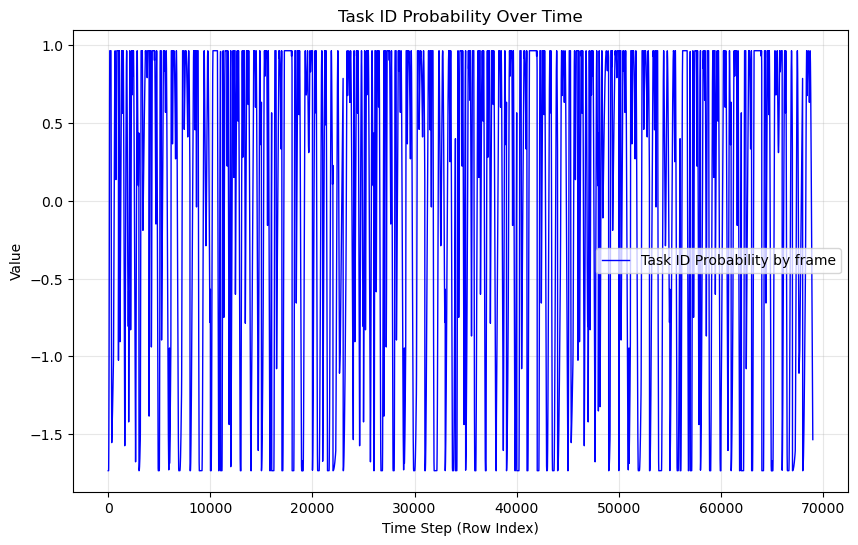

In [71]:
# plot distribution of task_id_prob 
plt.figure(figsize=(10, 6))

plt.plot(df.index, df['task_id_prob'], label='Task ID Probability by frame', color='blue', linewidth=1)

plt.title('Task ID Probability Over Time')
plt.xlabel('Time Step (Row Index)')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [72]:
bad_cols = [c for c in df.columns if df[c].dtype == "object"]
print("Object columns:", bad_cols)

Object columns: []


### Correlation

Text(0.5, 1.0, 'Feature Correlation Matrix')

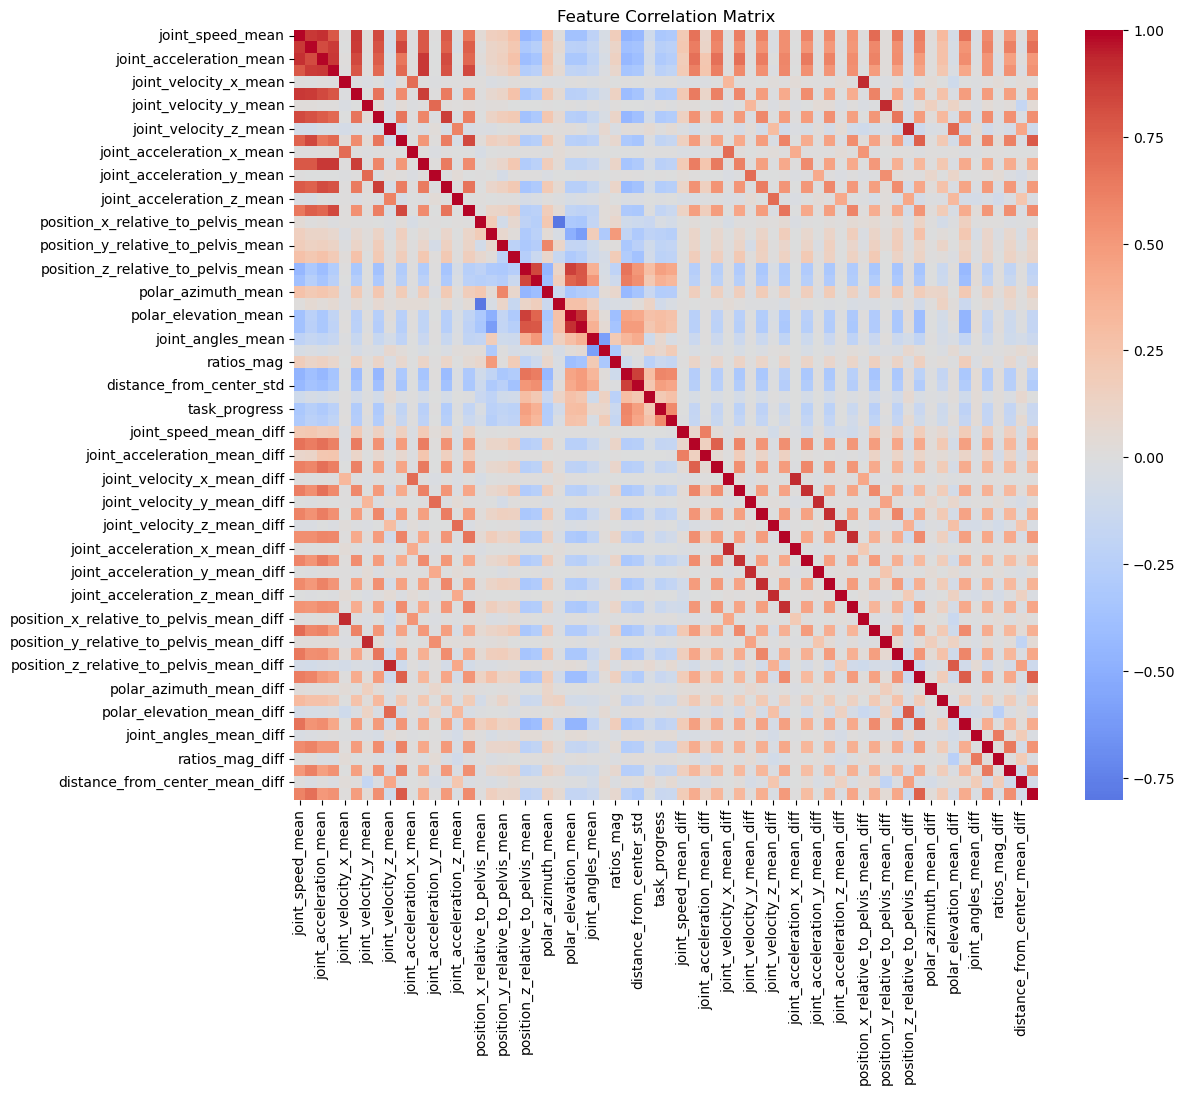

In [73]:
#correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")

### step_change signal: alignment

In [112]:
# df["step_change"] = df["step_id"].diff().fillna(0) != 0
# df["step_change"] = df["step_change"].astype(int)

# df.fillna(0, inplace=True)
# df.head()


In [113]:
# df["step_change"].describe()

In [114]:
# df["step_change"].sum()

In [75]:
df["task_id_prob"].describe()

count    6.900000e+04
mean    -1.812399e-16
std      1.000007e+00
min     -1.735396e+00
25%     -8.951151e-01
50%      4.240168e-01
75%      9.185244e-01
max      9.647640e-01
Name: task_id_prob, dtype: float64

In [76]:
df["task_id"].describe()

count    6.900000e+04
mean     9.226758e-17
std      1.000007e+00
min     -1.106948e+00
25%     -5.229895e-01
50%     -5.229895e-01
75%      6.449267e-01
max      2.396801e+00
Name: task_id, dtype: float64

In [77]:
feature_cols = [c for c in df.columns if c not in ["task_id", "task_progress", "t", "task_id_prob"]]

diff_cols = [c for c in feature_cols if "diff" in c]
absdiff_cols = [c for c in feature_cols if "absdiff" in c]

### Mutual Information

In [78]:
X = df[feature_cols]
y = df["task_id_prob"]

mi = mutual_info_regression(X.fillna(0), y)

mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

top_k = 20
top_features = mi_series.head(top_k).index

#CORE
X_filtered = X[top_features]

print("Top MI features:")
print(mi_series.head())

Top MI features:
distance_from_center_mean             0.363562
position_z_relative_to_pelvis_mean    0.327625
polar_elevation_mean                  0.295823
position_z_relative_to_pelvis_std     0.287176
distance_from_center_std              0.277763
dtype: float64


### Random Forest

In [79]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=5,
    min_samples_leaf=20,
)

model.fit(X_filtered.fillna(0), y)

feat_imp = pd.Series(model.feature_importances_, index=X_filtered.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top RF features:")
print(feat_imp.head())

Top RF features:
distance_from_center_mean             0.660993
joint_angles_mean                     0.156268
position_z_relative_to_pelvis_mean    0.062213
position_z_relative_to_pelvis_std     0.051990
position_x_relative_to_pelvis_mean    0.022815
dtype: float64


In [80]:
len(X_filtered.columns)

20

### SHAP interaction analysis

In [81]:
background = X_filtered.sample(n=100, random_state=42)

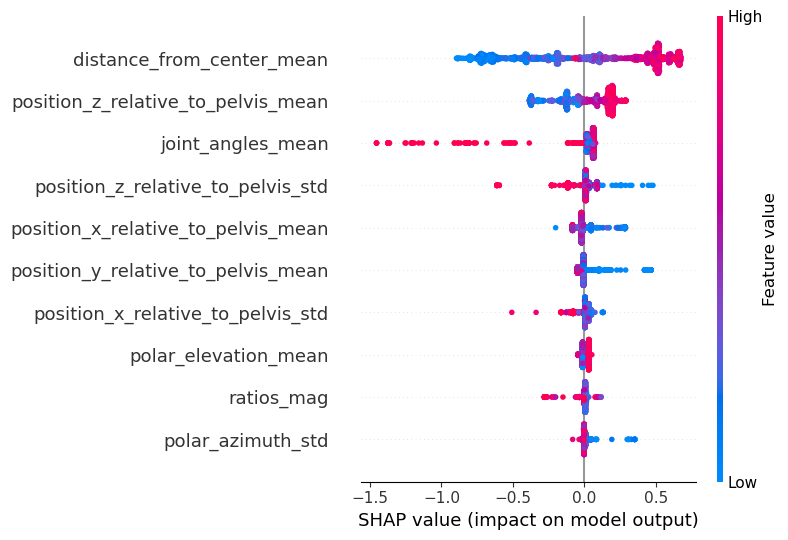

In [82]:
explainer = shap.TreeExplainer(model, background)

X_sample = X_filtered.sample(min(2000, len(X_filtered)), random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample,max_display=10)

In [41]:

# shap_interaction_values = explainer_interaction.shap_interaction_values(X_sample[select_col])
# shap.summary_plot(shap_interaction_values, X_sample[select_col],max_display=10)

In [ ]:
# shap_importance = np.abs(shap_values).mean(axis=0)

In [42]:
# from itertools import combinations

# top_for_combo = feat_imp.head(10).index

# combo_features = pd.DataFrame(index=df.index)
# print("Creating top combo features...")
# print(top_for_combo)

# for f1, f2 in combinations(top_for_combo, 2):
#     combo_features[f"{f1}_minus_{f2}"] = df[f1] - df[f2]
#     combo_features[f"{f1}_ratio_{f2}"] = df[f1] / (df[f2] + 1e-6)


# X_aug = pd.concat([X_filtered, combo_features], axis=1)

# NOW WE CAN SAY THE MOST IMPACTFUL FEATURES ARE:

## pol_angles | joint_angles

--------------------------------------------------

## Pattern analysis based on the raw .pt data

In [53]:
# --- CONFIG ---
pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\original\*.pt"
pt_files = sorted(glob.glob(pt_dir))

print(f"Found {len(pt_files)} pt files.")

# --- storage ---
vel_list = []
acc_list = []
pol_vec_list = []
pol_ang_list = []
joint_list = []
ratio_list = []
dist_ratio_list = []
step_list = []

# --- helper ---
def to_2d(x):
    """
    shape = (T, D)
    """
    x = np.array(x)

    if x.ndim == 1:
        return x[:, None]  # (T,) -> (T,1)

    elif x.ndim == 2:
        return x  # already (T, D)

    else:
        return x.reshape(x.shape[0], -1)  # (T, ...)->(T, D)


# --- LOAD LOOP ---
for f in pt_files:
    data = torch.load(f)

    feats = data["features"]
    labels = data["labels"]

    try:
        vel = to_2d(feats["velocity_xy"])
        acc = to_2d(feats["acceleration_xy"])
        pol_vec = to_2d(feats["pol_vectors"])
        pol_ang = to_2d(feats["pol_angles"])
        joint = to_2d(feats["joint_angles"])
        ratio = to_2d(feats["ratios"])
        dist_ratio = to_2d(feats["dist_ratios"])

        step = np.array(labels["step_id"])

        vel_list.append(vel)
        acc_list.append(acc)
        pol_vec_list.append(pol_vec)
        pol_ang_list.append(pol_ang)
        joint_list.append(joint)
        ratio_list.append(ratio)
        dist_ratio_list.append(dist_ratio)
        step_list.append(step)

    except KeyError as e:
        print(f"Missing key in {f}: {e}")
        continue


# --- STACK ---
X_vel = np.vstack(vel_list)
X_acc = np.vstack(acc_list)
X_pol_vec = np.vstack(pol_vec_list)
X_pol_ang = np.vstack(pol_ang_list)
X_joint = np.vstack(joint_list)
X_ratio = np.vstack(ratio_list)
X_dist_ratio = np.vstack(dist_ratio_list)
y_step = np.hstack(step_list)

# --- COMBINATIONS ---

# movement
X_move = np.hstack([X_vel, X_acc])

# pose
X_combo = np.hstack([X_pol_ang, X_joint])

# full pose
X_pose_full = np.hstack([X_pol_vec, X_pol_ang, X_joint])

# ratio
X_ratio_comb = np.hstack([X_ratio, X_dist_ratio])

# all
X_all = np.hstack([
    X_vel,
    X_acc,
    X_pol_vec,
    X_pol_ang,
    X_joint,
    X_ratio,
    X_dist_ratio
])

# --- SCALING ---
##acc+joint angle
scaler_acc_joint = StandardScaler()
X_acc_joint_scaled = scaler_acc_joint.fit_transform(np.hstack([X_acc, X_joint]))

scaler_combo = StandardScaler()
X_combo_scaled = scaler_combo.fit_transform(X_combo)

scaler_move = StandardScaler()
X_move_scaled = scaler_move.fit_transform(X_move)

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# individual features scaling   
scaler_vel = StandardScaler()
X_vel_scaled = scaler_vel.fit_transform(X_vel)

scaler_acc = StandardScaler()
X_acc_scaled = scaler_acc.fit_transform(X_acc)

scaler_pol_vec = StandardScaler()
X_pol_vec_scaled = scaler_pol_vec.fit_transform(X_pol_vec)

scaler_pol_ang = StandardScaler()
X_pol_ang_scaled = scaler_pol_ang.fit_transform(X_pol_ang)

scaler_joint = StandardScaler()
X_joint_scaled = scaler_joint.fit_transform(X_joint)

scaler_ratio = StandardScaler()
X_ratio_scaled = scaler_ratio.fit_transform(X_ratio)

scaler_dist_ratio = StandardScaler()
X_dist_ratio_scaled = scaler_dist_ratio.fit_transform(X_dist_ratio)



# --- PRINT ---
print("\n--- Shapes ---")
print("vel:", X_vel.shape)
print("acc:", X_acc.shape)
print("pol_vec:", X_pol_vec.shape)
print("pol_ang:", X_pol_ang.shape)
print("joint:", X_joint.shape)
print("pose:", X_pose.shape)
print("all:", X_all.shape)

NameError: name 'glob' is not defined

##### add step segmentation info

In [73]:
import json
def overlay_pt_markers(ax, video_names, pt_dir, target_steps=100):
    """
    Draw step change markers from .pt files
    """
    for row_idx, video_base_name in enumerate(video_names):

        pt_file = os.path.join(pt_dir, f"{video_base_name}.pt")

        if not os.path.exists(pt_file):
            continue

        data = torch.load(pt_file)
        labels = data["labels"]

        step_id = np.array(labels["step_id"])
        T = len(step_id)

        # --- step change ---
        step_change = np.where(np.diff(step_id) != 0)[0] + 1

        for i, x in enumerate(step_change):

            color = "black" #if i % 2 == 0 else "red"

            x_pos = (x / T) * target_steps

            ax.vlines(
                x=x_pos,
                ymin=row_idx,
                ymax=row_idx + 1,
                color=color,
                linewidth=3,
                zorder=5
            )

### Determine which features are more representative and robust

In [26]:
# npz_norm_path = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\train\norm"
# json_label_path = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\annotations\all"

# Gaussion Mixture Models(GMMs)
### Distribution based

In [74]:
from sklearn.mixture import GaussianMixture

def plot_hybrid_feature_heatmap_pt(
    X_stacked,
    pt_dir,
    n_clusters=5,
    target_steps=100
):
    """
    GMM clustering + heatmap + step/prob markers (based on .pt)
    """

    # --- 1. load pt files ---
    pt_files = sorted([f for f in os.listdir(pt_dir) if f.endswith(".pt")])

    if not pt_files:
        print("No .pt files found.")
        return None, None

    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # --- 2. GMM ---
    print(f"Performing GMM clustering (K={n_clusters})...")

    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type='full',
        random_state=42,
        reg_covar=1e-6
    )

    global_labels = gmm.fit_predict(X_stacked)

    # --- 3. build matrix ---
    parallel_matrix = []
    video_names = []
    current_ptr = 0

    for pf in pt_files:

        pt_path = os.path.join(pt_dir, pf)
        data = torch.load(pt_path)

        video_name = os.path.basename(pf).replace(".pt", "")

        # --- determine T ---
        labels = data["labels"]
        num_frames = len(labels["step_id"])

        # --- slice cluster labels ---
        video_labels = global_labels[current_ptr: current_ptr + num_frames]
        current_ptr += num_frames

        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled = video_labels[indices]

            parallel_matrix.append(resampled)
            video_names.append(video_name)

    parallel_matrix = np.array(parallel_matrix)

    # --- 4. plot ---
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))

    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20", n_clusters)

    ax = sns.heatmap(
        parallel_matrix,
        cmap=cmap,
        xticklabels=10,
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)}
    )

    # --- 5. overlay markers ---
    overlay_pt_markers(ax, video_names, pt_dir, target_steps=target_steps)

    # --- 6. style ---
    plt.title(f"GMM Feature Pattern (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)

    plt.xticks(np.linspace(0, target_steps, 21),
               [f"{i*5}%" for i in range(21)])

    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

# DBSCAN
### Density based 

In [55]:
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap
#plot_hybrid_feature_heatmap(X_scaled_xyn, npz_norm_path, n_clusters=cluster)
def plot_hybrid_feature_heatmap(X_stacked, data_path, n_clusters):

    eps=0.5
    min_samples=10
    target_steps=100
    # 1. Get all .npz files
    npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
    if not npz_files:
        print(".npz files not found in the specified directory.")
        return None, None
        
    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # 2. Perform DBSCAN Clustering
    print(f"Performing DBSCAN clustering (eps={eps}, min_samples={min_samples})...")
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    global_labels = dbscan.fit_predict(X_stacked)

    # Calculate cluster statistics
    unique_labels = np.unique(global_labels)
    n_clusters_found = len([l for l in unique_labels if l >= 0])
    has_noise = -1 in unique_labels
    
    print(f"DBSCAN result: {n_clusters_found} clusters identified.")
    if has_noise:
        print(f"Noise detected (Label -1).")

    # 3. Construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 

    for pf in npz_files:
        data = np.load(pf)
        video_name = os.path.basename(pf).replace("_norm.npz", "")
        
        num_frames = data['X_degree'].shape[0]
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. Prepare Heatmap and Color Mapping
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    # Custom colormap to handle -1 (Noise) as Grey
    base_n = max(1, n_clusters_found)
    base_cmap = plt.get_cmap("tab20", base_n)
    colors = [base_cmap(i) for i in range(base_n)]
    
    if has_noise:
        # Insert grey at the start for noise (-1)
        colors.insert(0, (0.5, 0.5, 0.5, 1.0)) 
        # Shift labels by +1 so that -1 becomes index 0 for the colormap
        plot_matrix = parallel_matrix + 1
        cbar_ticks = np.arange(n_clusters_found + 1)
        cbar_labels = ['Noise (-1)'] + [f'Cluster {i}' for i in range(n_clusters_found)]
    else:
        plot_matrix = parallel_matrix
        cbar_ticks = np.arange(n_clusters_found)
        cbar_labels = [f'Cluster {i}' for i in range(n_clusters_found)]

    my_cmap = ListedColormap(colors)

    # 5. Plot heatmap
    sns.heatmap(
        plot_matrix, 
        cmap=my_cmap, 
        xticklabels=10, 
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster Analysis', 'ticks': cbar_ticks}
    )
    
    # Update colorbar tick labels
    colorbar = plt.gca().collections[0].colorbar
    colorbar.set_ticklabels(cbar_labels)

    plt.title(f"DBSCAN Hybrid Feature Pattern Analysis (eps={eps})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return dbscan, parallel_matrix

# KMeans
### Centroid based

In [ ]:
# def plot_hybrid_feature_heatmap(X_stacked, data_path, json_label_path, n_clusters=5, target_steps=100):
#     # get all .npz files
#     npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
#     if not npz_files:
#         print(".npz files not found in the specified directory.")
#         return

#     # 2. global K-Means clustering on the stacked features
#     print("Performing K-Means clustering on combined features...")
    
#     # use different clustering methods here if needed(gaussion mixture, hierarchical clustering, etc.)
#     # KMEANS
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     global_labels = kmeans.fit_predict(X_stacked)

#     # 


#     # 3. construct parallel matrix for each video
#     parallel_matrix = []
#     video_names = []
#     current_ptr = 0 #

#     for pf in npz_files:
#         data = np.load(pf)
#         video_name = os.path.basename(pf).replace("_norm.npz", "")
        
#         # get number of frames for this video
#         num_frames = data['X_degree'].shape[0]
        
#         # extract corresponding cluster labels for this video's frames
#         video_labels = global_labels[current_ptr : current_ptr + num_frames]

#         current_ptr += num_frames
        
#         # align (Resampling to 0-100%)
#         if len(video_labels) > 0:
#             indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
#             resampled_labels = video_labels[indices]
            
#             parallel_matrix.append(resampled_labels)
#             video_names.append(video_name)

#     # 4. plot heatmap
#     parallel_matrix = np.array(parallel_matrix)
#     plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
#     cmap = plt.get_cmap("tab20", n_clusters)
#     ax = sns.heatmap(parallel_matrix, 
#                 cmap=cmap, 
#                 xticklabels=10, 
#                 yticklabels=video_names,
#                 cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)})
                
#     # --- insert labeled markers ---
#     if json_label_path is not None:
#         overlay_json_markers(ax, video_names, data_path, json_label_path, target_steps)
#     # -----------------------

#     plt.title(f"Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
#     plt.xlabel("Task Progress (%)", fontsize=12)
#     plt.ylabel("Video Samples", fontsize=12)
    
#     # 5% interval ticks
#     plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
#     plt.tight_layout()
#     plt.show()

#     return ax, parallel_matrix

In [41]:
def plot_hybrid_feature_heatmap_pt(
    X_stacked,
    pt_dir,
    n_clusters=5,
    target_steps=100
):
    """
    K-Means clustering + heatmap + step/prob markers (based on .pt)
    """

    # --- 1. load pt files ---
    pt_files = sorted([f for f in os.listdir(pt_dir) if f.endswith(".pt")])

    if not pt_files:
        print("No .pt files found.")
        return None, None

    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # --- 2. K-Means ---
    print(f"Performing K-Means clustering (K={n_clusters})...")

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    global_labels = kmeans.fit_predict(X_stacked)

    # --- 3. build matrix ---
    parallel_matrix = []
    video_names = []
    current_ptr = 0

    for pf in pt_files:

        pt_path = os.path.join(pt_dir, pf)
        data = torch.load(pt_path)

        video_name = os.path.basename(pf).replace(".pt", "")

        # --- determine T ---
        labels = data["labels"]
        num_frames = len(labels["step_id"])

        # --- slice cluster labels ---
        video_labels = global_labels[current_ptr: current_ptr + num_frames]
        current_ptr += num_frames

        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled = video_labels[indices]

            parallel_matrix.append(resampled)
            video_names.append(video_name)

    parallel_matrix = np.array(parallel_matrix)

    # --- 4. plot ---
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))

    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20", n_clusters)

    ax = sns.heatmap(
        parallel_matrix,
        cmap=cmap,
        xticklabels=10,
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)}
    )

    # --- 5. overlay markers ---
    overlay_pt_markers(ax, video_names, pt_dir, target_steps=target_steps)

    # --- 6. style ---
    plt.title(f"K-Means Feature Pattern (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)

    plt.xticks(np.linspace(0, target_steps, 21),
               [f"{i*5}%" for i in range(21)])

    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

In [75]:
cluster = 5

# Individual Features

In [ ]:
    # X_stacked,
    # pt_dir,
    # n_clusters=5,
    # target_steps=100,
    # use_prob=False

In [98]:
pt_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\original"

Performing GMM clustering (K=7)...


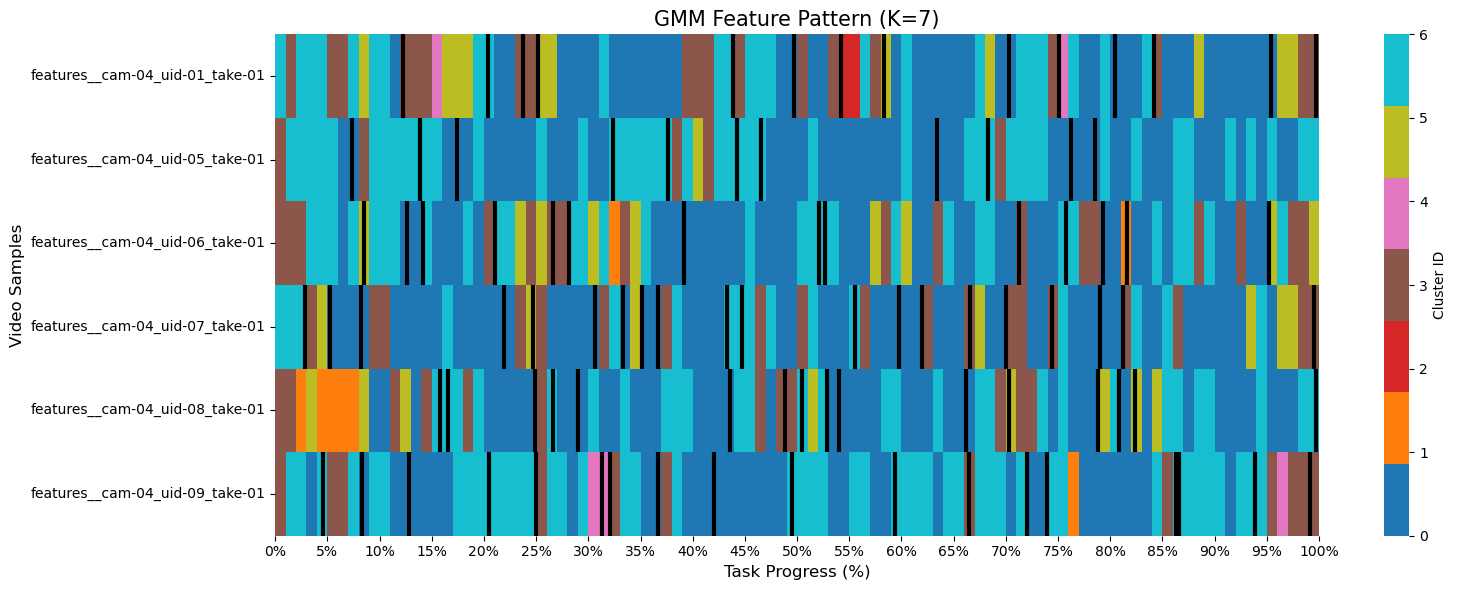

In [96]:
# pol angle
ax_pol_ang, matrix_pol_ang = plot_hybrid_feature_heatmap_pt(X_pol_ang_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


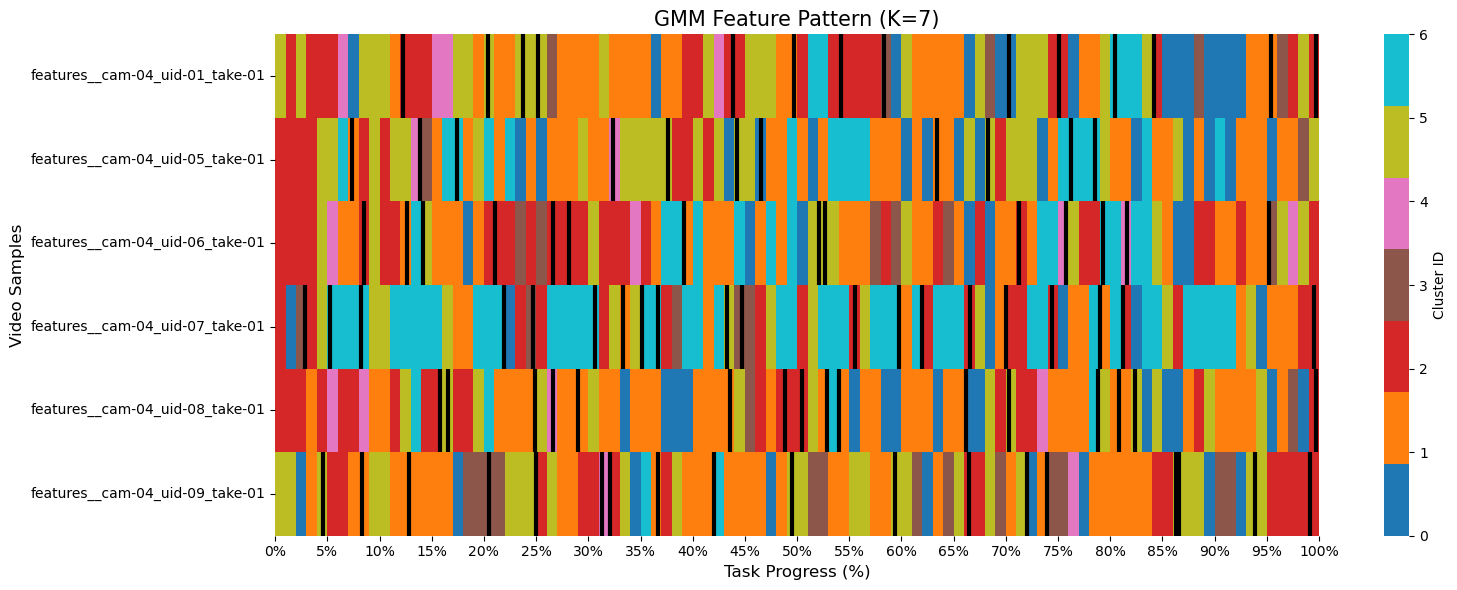

In [97]:
# joint angle
ax_joint, matrix_joint = plot_hybrid_feature_heatmap_pt(X_joint_scaled, pt_dir, n_clusters=7, target_steps=100) 

Performing GMM clustering (K=7)...


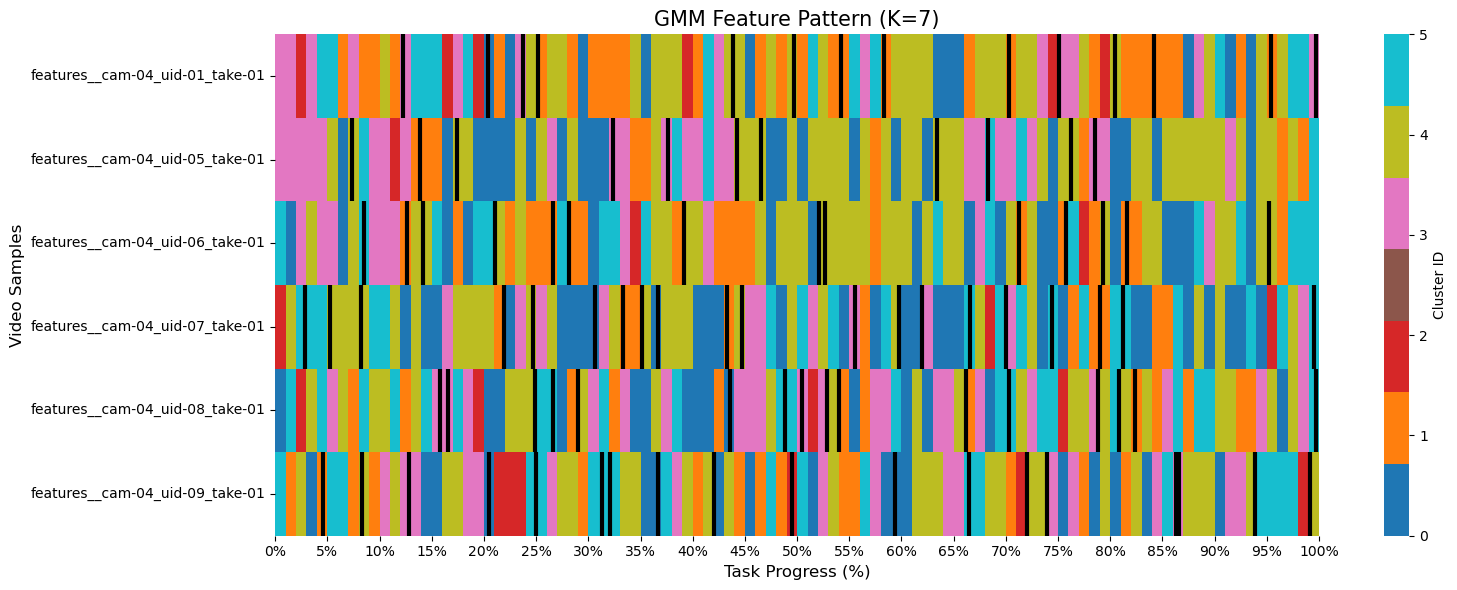

In [94]:
#acc
ax_acc, matrix_acc = plot_hybrid_feature_heatmap_pt(X_acc_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


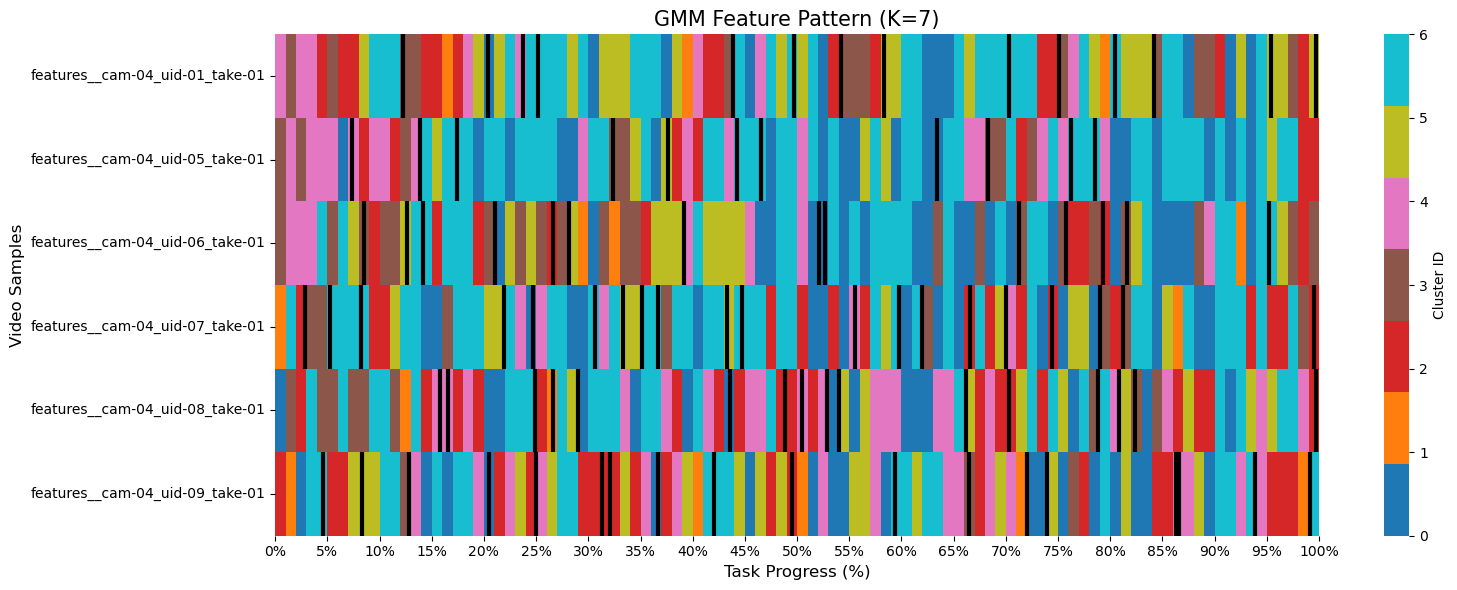

In [93]:
#vel:
ax_vel, matrix_vel = plot_hybrid_feature_heatmap_pt(X_vel_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


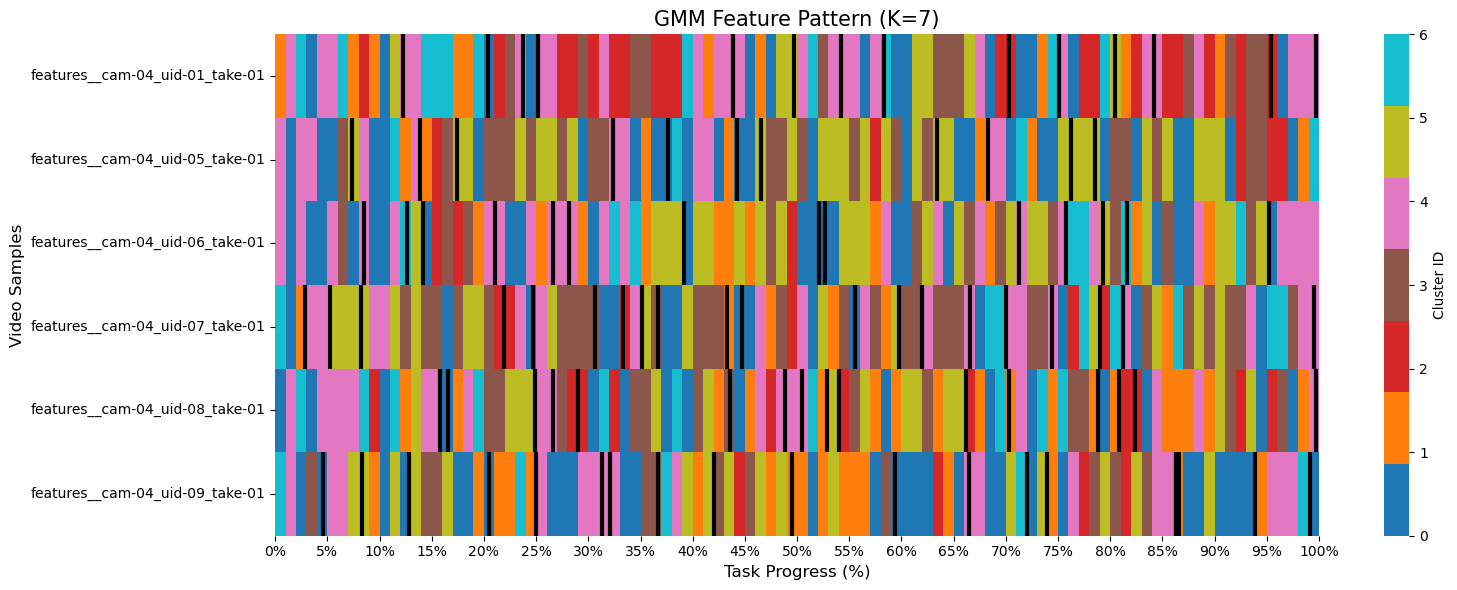

In [92]:
#acc + joint angle
ax_acc_joint, matrix_acc_joint = plot_hybrid_feature_heatmap_pt(X_acc_joint_scaled, pt_dir, n_clusters=7, target_steps=100)

Performing GMM clustering (K=7)...


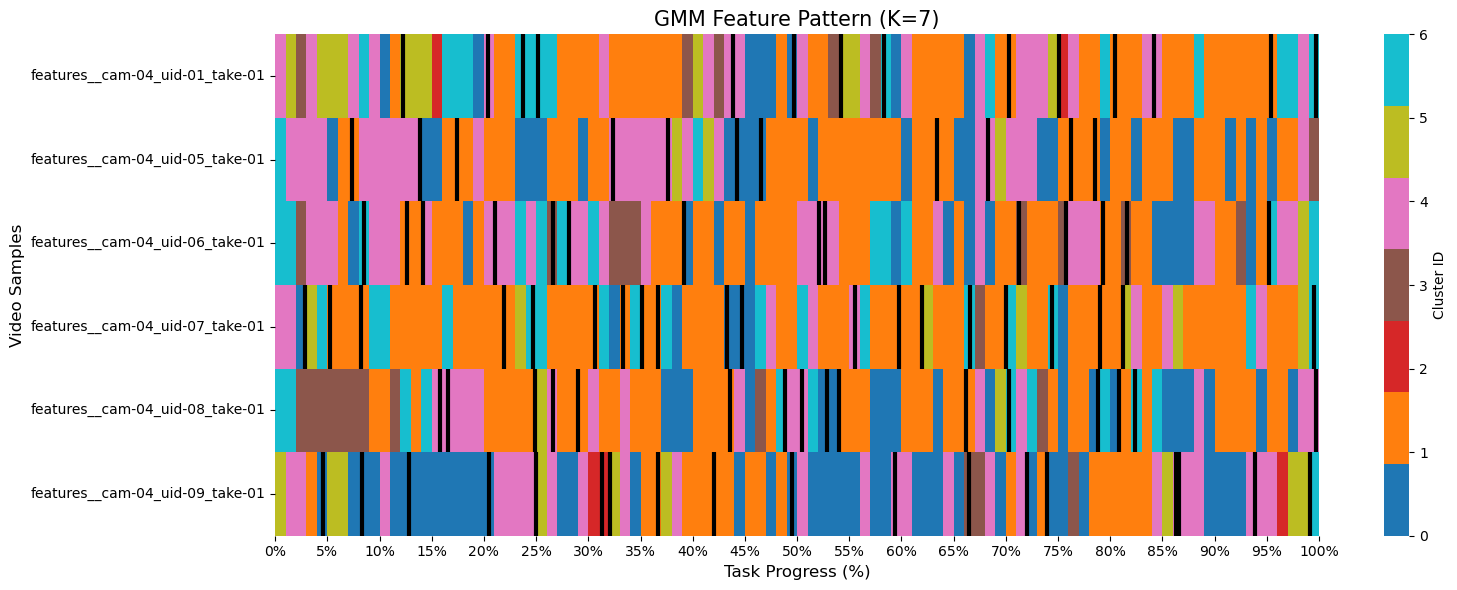

In [91]:
# combo:
ax_combo, matrix_combo = plot_hybrid_feature_heatmap_pt(X_combo_scaled, pt_dir, n_clusters=7, target_steps=100)

### CLUSTERING

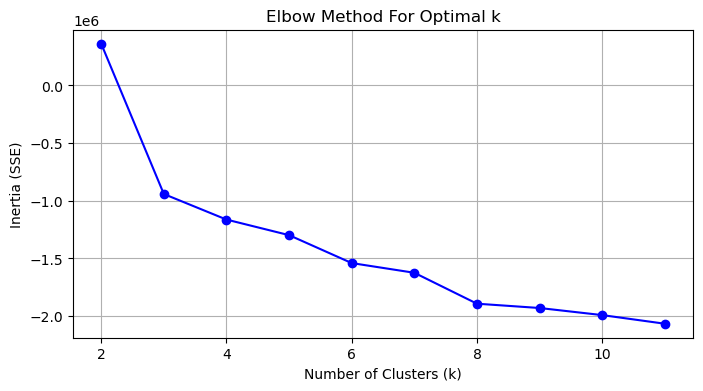

In [54]:
inertias = []
K_range = range(2, 12) #

X_stacked = X_combo_scaled  # Change this to analyze different feature combinations
X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

for k in K_range:
    # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(X_scaled_deg_speed)
    # inertias.append(kmeans.inertia_)
    # GMMs
    gmm = GaussianMixture(
        n_components=k, 
        covariance_type='full', 
        random_state=42, 
        reg_covar=1e-6  # Added small value for numerical stability
    )
    
    # Fit the model and predict labels
    gmm.fit(X_stacked)
    inertias.append(gmm.bic(X_stacked))  # Using BIC for GMM instead of inertia

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [55]:

optimal_k = 8

gmm = GaussianMixture(
    n_components=optimal_k, 
    covariance_type='full', 
    random_state=42, 
    reg_covar=1e-6  # Added small value for numerical stability
)

# Fit the model and predict labels
labels = gmm.fit_predict(X_stacked)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 13730 16.3%
cluster 1: 617 0.7%
cluster 2: 15062 17.8%
cluster 3: 22537 26.7%
cluster 4: 4380 5.2%
cluster 5: 8225 9.7%
cluster 6: 15093 17.9%
cluster 7: 4822 5.7%


## TSNE visulization

In [ ]:
# from sklearn.manifold import TSNE
# import pandas as pd

# sample_size = 3000 
# indices = np.linspace(0, len(X_scaled_deg_speed_accel) - 1, sample_size).astype(int)
# X_sample = X_scaled_deg_speed_accel[indices]
# labels_sample = labels[indices]

# tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
# X_tsne = tsne.fit_transform(X_sample)


# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
#                       c=labels_sample, 
#                       cmap='tab10', 
#                       alpha=0.6, 
#                       s=15)


# legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
# plt.gca().add_artist(legend1)

# plt.title(f"t-SNE Visualization of Action Clusters (K={optimal_k})", fontsize=15)
# plt.xlabel("t-SNE dimension 1")
# plt.ylabel("t-SNE dimension 2")
# plt.grid(True, alpha=0.3)
# plt.show()

### Visulize Selected Postures of Each Cluster

In [29]:
def plot_skeleton(points, title, ax):
    EDGES = [
        # Face
        (0, 1), (0, 2), (1, 3), (2, 4), 
        # Upper Body & Arms
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        # Torso
        (5, 11), (6, 12), (11, 12),
        # Lower Body & Legs
        (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    pts = points.reshape(17, 2)
    ax.scatter(pts[:, 0], -pts[:, 1], c='red', s=20) 
    for edge in EDGES:
        ax.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.axis('equal')
    ax.axis('off') 

# find representative postures for each cluster and plot them
plt.figure(figsize=(20, 5))

# X_scaled_deg.shape[1] = 9
# X_pos.shape[1] = 22 (skeleton points)
# Reshaped XYN Features:     (61104, 34)
X_pos = X_xyn.reshape(-1, 17, 2)

for i in range(optimal_k):
    cluster_indices = np.where(labels == i)[0]
    
    if len(cluster_indices) > 0:
        cluster_postures = X_pos[cluster_indices]

        representative_posture = np.mean(cluster_postures, axis=0)
        
        ax = plt.subplot(1, optimal_k, i+1)
        
        percentage = (len(cluster_indices) / len(labels)) * 100
        title_str = f"Cluster {i}\n({percentage:.1f}%)"
        
        plot_skeleton(representative_posture, title_str, ax)
    else:
        print(f"Warning: Cluster {i} has no samples.")

plt.suptitle("Representative Postures Derived from Degree-based Clustering", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

NameError: name 'X_xyn' is not defined

<Figure size 2000x500 with 0 Axes>

## Conclusions:

## 1. Feature selection and combination

## 2. Posture cluster and step segmentation